In [1]:
import os
import shutil
import numpy as np
from netCDF4 import Dataset

# =========================
# 1. 
# =========================
input_dir = "/scratch/smliu01/1d_model/ens10_1k"
output_root = "/scratch/smliu01/1d_model/forcing_sweep"

# =========================
# 2. parameter sweep 
#    
# =========================
scale_factors = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]

# =========================
# 3. 
#     forcing 
#    
# =========================
FORCE_VAR_NAMES = ["forcing"
    # :
    # "forcing",
    # "epz",
    # "total_epz",
    # "wave_forcing",
]

# =========================
# 4. /
# =========================
EXCLUDE_VARS = {
    "time", "times", "date", "datesec", "datesec0",
    "lat", "latitude", "lon", "longitude",
    "lev", "level", "levels", "plev", "ilev",
    "z", "zz", "height", "heights",
    "x", "y"
}

def scale_tag(scale):
    """
    
     0.8 -> scale_0p80
         1.2 -> scale_1p20
    """
    return f"scale_{scale:.2f}".replace(".", "p")

def should_scale_var(var_name, var_obj):
    """
    
    """
    # 
    if FORCE_VAR_NAMES:
        return var_name in FORCE_VAR_NAMES

    # /
    lname = var_name.lower()
    if lname in EXCLUDE_VARS:
        return False

    # 
    if getattr(var_obj, "ndim", 0) == 0:
        return False

    # 
    if not np.issubdtype(var_obj.dtype, np.number):
        return False

    return True

def copy_global_attributes(src, dst):
    for attr in src.ncattrs():
        dst.setncattr(attr, src.getncattr(attr))

def copy_dimensions(src, dst):
    for dname, dim in src.dimensions.items():
        dst.createDimension(dname, None if dim.isunlimited() else len(dim))

def copy_variable(src_var, dst, scale=None):
    """
     scale  None
    """
    fill_value = getattr(src_var, "_FillValue", None)

    # 
    if fill_value is not None:
        dst_var = dst.createVariable(
            src_var.name, src_var.dtype, src_var.dimensions,
            zlib=True, fill_value=fill_value
        )
    else:
        dst_var = dst.createVariable(
            src_var.name, src_var.dtype, src_var.dimensions,
            zlib=True
        )

    #  _FillValue createVariable 
    for attr in src_var.ncattrs():
        if attr == "_FillValue":
            continue
        dst_var.setncattr(attr, src_var.getncattr(attr))

    # 
    data = src_var[:]

    # 
    if scale is not None:
        data = data * scale
        # 
        dst_var.setncattr("scale_factor_applied", scale)

    # 
    dst_var[:] = data

def process_one_file(infile, outfile, scale):
    with Dataset(infile, "r") as src, Dataset(outfile, "w") as dst:
        copy_dimensions(src, dst)
        copy_global_attributes(src, dst)

        # 
        dst.setncattr("source_file", os.path.basename(infile))
        dst.setncattr("forcing_scale_factor", scale)

        scaled_vars = []
        unscaled_vars = []

        for vname, src_var in src.variables.items():
            if should_scale_var(vname, src_var):
                copy_variable(src_var, dst, scale=scale)
                scaled_vars.append(vname)
            else:
                copy_variable(src_var, dst, scale=None)
                unscaled_vars.append(vname)

        dst.setncattr("scaled_variables", ", ".join(scaled_vars))
        dst.setncattr("unscaled_variables", ", ".join(unscaled_vars))

        print(f"[OK] {os.path.basename(infile)}  ->  {outfile}")
        print(f"     scaled vars: {scaled_vars}")

def main():
    os.makedirs(output_root, exist_ok=True)

    nc_files = sorted([
        f for f in os.listdir(input_dir)
        if f.endswith(".nc")
    ])

    if not nc_files:
        raise FileNotFoundError(f"No .nc files found in {input_dir}")

    print(f"[INFO] Found {len(nc_files)} forcing files.")

    for scale in scale_factors:
        tag = scale_tag(scale)
        outdir = os.path.join(output_root, tag)
        os.makedirs(outdir, exist_ok=True)

        print("=" * 70)
        print(f"[INFO] Generating scaled forcing set: {tag} (scale={scale})")
        print(f"[INFO] Output folder: {outdir}")

        for fname in nc_files:
            infile = os.path.join(input_dir, fname)
            outfile = os.path.join(outdir, fname)
            process_one_file(infile, outfile, scale)

    print("=" * 70)
    print("[DONE] All scaled forcing ensembles have been generated.")
    print(f"[DONE] Output root: {output_root}")

if __name__ == "__main__":
    main()

[INFO] Found 10 forcing files.
[INFO] Generating scaled forcing set: scale_0p50 (scale=0.5)
[INFO] Output folder: /scratch/smliu01/1d_model/forcing_sweep/scale_0p50
[OK] forcing_total_1000_ens00.nc  ->  /scratch/smliu01/1d_model/forcing_sweep/scale_0p50/forcing_total_1000_ens00.nc
     scaled vars: ['forcing']
[OK] forcing_total_1000_ens01.nc  ->  /scratch/smliu01/1d_model/forcing_sweep/scale_0p50/forcing_total_1000_ens01.nc
     scaled vars: ['forcing']
[OK] forcing_total_1000_ens02.nc  ->  /scratch/smliu01/1d_model/forcing_sweep/scale_0p50/forcing_total_1000_ens02.nc
     scaled vars: ['forcing']
[OK] forcing_total_1000_ens03.nc  ->  /scratch/smliu01/1d_model/forcing_sweep/scale_0p50/forcing_total_1000_ens03.nc
     scaled vars: ['forcing']
[OK] forcing_total_1000_ens04.nc  ->  /scratch/smliu01/1d_model/forcing_sweep/scale_0p50/forcing_total_1000_ens04.nc
     scaled vars: ['forcing']
[OK] forcing_total_1000_ens05.nc  ->  /scratch/smliu01/1d_model/forcing_sweep/scale_0p50/forcing_tot

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

# =========================================================
# 1. 
# =========================================================
root_dir = "/scratch/smliu01/1d_model/forcing_sweep"
save_dir = os.path.join(root_dir, "figures")
os.makedirs(save_dir, exist_ok=True)

# =========================================================
# 2. 
#     forcing 
# =========================================================
var_name = "forcing"

# =========================================================
# 3.  nc  forcing 
# =========================================================
def read_forcing_series(ncfile, var_name):
    with Dataset(ncfile, "r") as ds:
        if var_name not in ds.variables:
            raise KeyError(
                f"{var_name} not found in {ncfile}. "
                f"Available vars: {list(ds.variables.keys())}"
            )
        x = ds.variables[var_name][:]

    x = np.asarray(x)

    if np.ma.isMaskedArray(x):
        x = x.filled(np.nan)

    x = np.squeeze(x)

    if x.ndim == 2:
        x = x.reshape(-1)
    elif x.ndim == 1:
        pass
    else:
        raise ValueError(
            f"{ncfile}: variable {var_name} has unsupported shape {x.shape}"
        )

    return x

# =========================================================
# 4.  scale 
#    scale_0p80 -> 0.80
# =========================================================
def parse_scale(group_name):
    s = group_name.replace("scale_", "").replace("p", ".")
    return float(s)

# =========================================================
# 5.  scale 
# =========================================================
scale_dirs = sorted([
    d for d in glob.glob(os.path.join(root_dir, "scale_*"))
    if os.path.isdir(d)
])

if len(scale_dirs) == 0:
    raise FileNotFoundError(f"No scale_* folders found under {root_dir}")

print(f"[INFO] Found {len(scale_dirs)} scale groups")

# =========================================================
# 6.  scale 
#    (a) ensemble mean of mean(forcing)
#    (b) ensemble mean of mean(abs(forcing))
# =========================================================
results = []

for sdir in scale_dirs:
    group_name = os.path.basename(sdir)
    scale_val = parse_scale(group_name)

    ncfiles = sorted(glob.glob(os.path.join(sdir, "*.nc")))
    if len(ncfiles) == 0:
        print(f"[WARN] No nc files in {sdir}, skip")
        continue

    member_means = []
    member_abs_means = []

    for f in ncfiles:
        ts = read_forcing_series(f, var_name)

        member_means.append(np.nanmean(ts))
        member_abs_means.append(np.nanmean(np.abs(ts)))

    member_means = np.array(member_means)
    member_abs_means = np.array(member_abs_means)

    ens_mean = np.nanmean(member_means)
    ens_std = np.nanstd(member_means)

    ens_abs_mean = np.nanmean(member_abs_means)
    ens_abs_std = np.nanstd(member_abs_means)

    results.append({
        "group_name": group_name,
        "scale": scale_val,
        "ens_mean": ens_mean,
        "ens_std": ens_std,
        "ens_abs_mean": ens_abs_mean,
        "ens_abs_std": ens_abs_std,
        "n_members": len(ncfiles),
    })

    print(
        f"[INFO] {group_name}: "
        f"mean={ens_mean:.6g} ± {ens_std:.6g}, "
        f"abs_mean={ens_abs_mean:.6g} ± {ens_abs_std:.6g}"
    )

#  scale 
results = sorted(results, key=lambda d: d["scale"])

scales = np.array([r["scale"] for r in results])
ens_means = np.array([r["ens_mean"] for r in results])
ens_stds = np.array([r["ens_std"] for r in results])

ens_abs_means = np.array([r["ens_abs_mean"] for r in results])
ens_abs_stds = np.array([r["ens_abs_std"] for r in results])

# =========================================================
# 7. 1 mean(forcing)
# =========================================================
plt.figure(figsize=(8, 5))
plt.errorbar(scales, ens_means, yerr=ens_stds, marker='o', capsize=4)
plt.xlabel("Forcing scale factor")
plt.ylabel(f"Ensemble mean of time-mean {var_name}")
plt.title(f"Scalar ensemble mean vs forcing scale ({var_name})")
plt.grid(True, alpha=0.3)
plt.tight_layout()

outfig1 = os.path.join(save_dir, f"scalar_ensemble_mean_{var_name}.png")
plt.savefig(outfig1, dpi=200)
plt.close()

print(f"[DONE] Saved: {outfig1}")

# =========================================================
# 8. 2mean(abs(forcing))
# =========================================================
plt.figure(figsize=(8, 5))
plt.errorbar(scales, ens_abs_means, yerr=ens_abs_stds, marker='o', capsize=4)
plt.xlabel("Forcing scale factor")
plt.ylabel(f"Ensemble mean of time-mean |{var_name}|")
plt.title(f"Scalar ensemble mean of amplitude vs forcing scale ({var_name})")
plt.grid(True, alpha=0.3)
plt.tight_layout()

outfig2 = os.path.join(save_dir, f"scalar_ensemble_absmean_{var_name}.png")
plt.savefig(outfig2, dpi=200)
plt.close()

print(f"[DONE] Saved: {outfig2}")

# =========================================================
# 9. 
# =========================================================
txtfile = os.path.join(save_dir, f"scalar_ensemble_summary_{var_name}.txt")
with open(txtfile, "w") as f:
    f.write(
        "group_name scale n_members ens_mean ens_std ens_abs_mean ens_abs_std\n"
    )
    for r in results:
        f.write(
            f"{r['group_name']} "
            f"{r['scale']:.6f} "
            f"{r['n_members']} "
            f"{r['ens_mean']:.10e} "
            f"{r['ens_std']:.10e} "
            f"{r['ens_abs_mean']:.10e} "
            f"{r['ens_abs_std']:.10e}\n"
        )

print(f"[DONE] Saved summary: {txtfile}")

[INFO] Found 6 scale groups
[INFO] scale_0p50: mean=0.0143563 ± 3.99078e-07, abs_mean=0.0149428 ± 1.25337e-06
[INFO] scale_0p80: mean=0.0229701 ± 6.41114e-07, abs_mean=0.0239086 ± 2.00501e-06
[INFO] scale_1p00: mean=0.0287127 ± 7.98156e-07, abs_mean=0.0298857 ± 2.50674e-06
[INFO] scale_1p20: mean=0.0344552 ± 9.62442e-07, abs_mean=0.0358628 ± 3.01027e-06
[INFO] scale_1p50: mean=0.043069 ± 1.2037e-06, abs_mean=0.0448285 ± 3.76194e-06
[INFO] scale_2p00: mean=0.0574253 ± 1.59631e-06, abs_mean=0.0597714 ± 5.01347e-06
[DONE] Saved: /scratch/smliu01/1d_model/forcing_sweep/figures/scalar_ensemble_mean_forcing.png
[DONE] Saved: /scratch/smliu01/1d_model/forcing_sweep/figures/scalar_ensemble_absmean_forcing.png
[DONE] Saved summary: /scratch/smliu01/1d_model/forcing_sweep/figures/scalar_ensemble_summary_forcing.txt


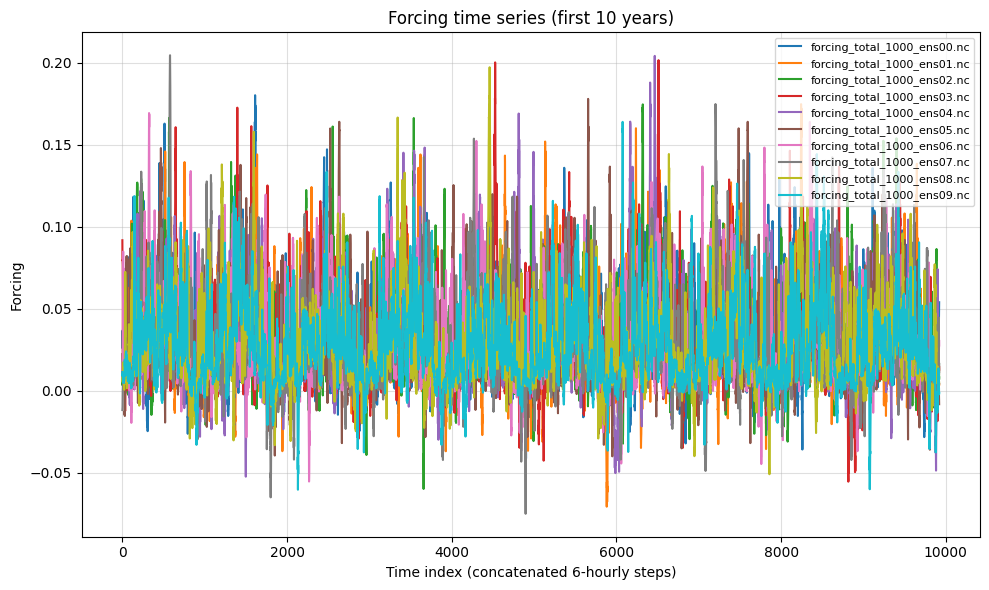

In [10]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

forcing_dir = '/scratch/smliu01/1d_model/forcing_sweep/scale_1p00'
forcing_files = sorted(glob.glob(os.path.join(forcing_dir, '*.nc')))

n_years = 10
steps_per_year = 992

plt.figure(figsize=(10, 6))

for forcing_file in forcing_files:
    with nc.Dataset(forcing_file, 'r') as ds:
        if 'forcing' not in ds.variables:
            print(f"WARNING: 'forcing' not found in {forcing_file}")
            continue

        forcing = np.array(ds.variables['forcing'][:])

        if forcing.ndim != 2:
            print(f"WARNING: forcing in {forcing_file} is not 2D, shape={forcing.shape}")
            continue

        nyear_avail, nstep_avail = forcing.shape
        max_years = min(n_years, nyear_avail)

        selected = []
        for year in range(max_years):
            selected.append(forcing[year, :])

        forcing_concat = np.concatenate(selected)
        time_concat = np.arange(forcing_concat.size)

        plt.plot(time_concat, forcing_concat, label=os.path.basename(forcing_file))

plt.xlabel('Time index (concatenated 6-hourly steps)')
plt.ylabel('Forcing')
plt.title(f'Forcing time series (first {n_years} years)')
plt.grid(True, alpha=0.4)

if len(forcing_files) <= 12:
    plt.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

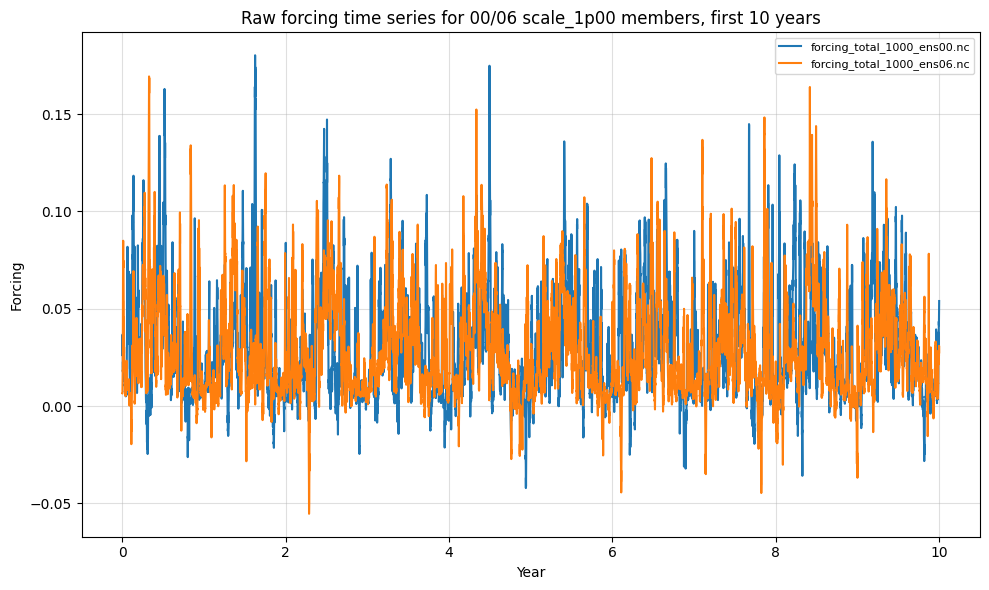

In [11]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import os

#  00  06  forcing 
# forcing.shape = (1000, 992)
#  0  1  992  6-hourly time steps

n_years = 10
steps_per_year = 992

plt.figure(figsize=(10, 6))

for idx, forcing_file in enumerate(forcing_files):
    basename = os.path.basename(forcing_file)

    #  00.nc  06.nc 
    if not (basename.endswith('00.nc') or basename.endswith('06.nc')):
        continue

    with nc.Dataset(forcing_file, 'r') as ds:
        if 'forcing' not in ds.variables:
            print(f"WARNING: 'forcing' not found in {forcing_file}")
            continue

        forcing = np.array(ds.variables['forcing'][:])

        #  forcing.shape = (nyear, steps_per_year)
        if forcing.ndim != 2:
            print(f"WARNING: forcing in {basename} is not 2D, shape={forcing.shape}")
            continue

        nyear_avail, nstep_avail = forcing.shape

        if nstep_avail != steps_per_year:
            print(
                f"WARNING: expected {steps_per_year} steps/year, "
                f"but got {nstep_avail} in {basename}"
            )
            continue

        max_years = min(n_years, nyear_avail)

        # 
        # forcing[0, :], forcing[1, :], ..., forcing[max_years-1, :]
        forcing_to_plot = forcing[:max_years, :].reshape(-1)

        # 0  10
        time = np.arange(forcing_to_plot.size) / steps_per_year

        plt.plot(time, forcing_to_plot, label=basename)

plt.xlabel('Year')
plt.ylabel('Forcing')
plt.title(f'Raw forcing time series for 00/06 scale_1p00 members, first {n_years} years')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()